# Comparing the baseline old vs the RASCAL logic approach

This notebook compares two CSV outputs:

- **Baseline**: `filtered_pairs_500_800_HiGHS_CMD_threads_8.csv`
- **RASCAL approach**: `filtered_pairs_500_800_HiGHS_CMD_threads_8_RASCAL_approach.csv`

Main question:

> Did the RASCAL approach give a useful lower bound and avoid going through the solver, while still producing comparable results?

The notebook checks:

1. Whether the same molecular pairs are present in both files.
2. Whether solver calls were reduced.
3. Whether the returned distances/lower bounds changed.
5. Which pairs changed behavior between the two approaches.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('../../example/filter_mass_diff_and_size')
BASELINE_PATH =  DATA_DIR /'filtered_pairs_500_800_HiGHS_CMD_threads_8.csv'
RASCAL_PATH = DATA_DIR /'filtered_pairs_500_800_HiGHS_CMD_threads_8_RASCAL_approach2.csv'

baseline = pd.read_csv(BASELINE_PATH)
rascal = pd.read_csv(RASCAL_PATH)

print("Baseline shape:", baseline.shape)
print("RASCAL shape:", rascal.shape)

display(baseline.head())
display(rascal.head())

Baseline shape: (47, 18)
RASCAL shape: (47, 21)


,pair_id,smiles1,smiles2,mass1,mass2,mass_diff,runtime_sec,runtime_inside_mces,distance,compute_mode,skipped,solverCalled,ilp_solver,raw_mces_result,error_message,result_type,is_exact,is_lower_bound
0,1879,[H][C@](COC(=O)CCCCCCCCC)(COC(=O)CCCCCCCCCCCCC...,[H][C@](COC(=O)CCCCCCCCC)(COC(=O)CCCCCCCCCCCCC...,723.177,723.177,2.273737e-13,18.516819,16.539669,4.0,1.0,0,1,1.0,"(0, 3.99999999999941, 16.539669275283813, 1, 1)",NaN,exact,1,0
1,3585,[H][C@@](COC(=O)CCCCCCCCCCCCCCC)(COC(=O)CCCCCC...,[H][C@@](COC(=O)CCCCCCCCCCCCC(C)CC)(COC(=O)CCC...,793.312,793.312,1.136868e-13,5.443820,4.268368,4.0,1.0,0,1,1.0,"(0, 3.9999999999988765, 4.2683680057525635, 1, 1)",NaN,exact,1,0
2,3623,CC[C@H](O)\C=C\C=C/C\C=C/C\C=C/C\C=C/CCCC(=O)O...,CC1OC(CC(C1OS(C)(=O)=O)N1CC1)OC1CC(O)(CC2=C(O)...,602.897,601.630,1.267000e+00,1.123909,0.002992,25.0,2.0,0,0,NaN,"(0, 25.0, 0.0029916763305664062, 2)",NaN,lower_bound,0,1
3,7864,CCCCC[C@H](O)\C=C\[C@H]1[C@H](O)CC(=O)[C@@H]1C...,[H][C@@](COC(=O)CCCCCCCCCCCCCCCCCC)(COC(=O)CCC...,764.931,765.258,3.270000e-01,1.003926,0.001994,20.0,2.0,0,0,NaN,"(0, 20.0, 0.0019943714141845703, 2)",NaN,lower_bound,0,1
4,8016,CCCCC\C=C/C\C=C/C\C=C/CCCCC(=O)O[C@H](COC(=O)C...,[H][C@@](COC(=O)CCCCCCCCCCCCCCCCC(C)C)(COC(=O)...,792.004,793.312,1.308000e+00,0.977670,0.002113,17.0,2.0,0,0,NaN,"(0, 17.0, 0.00211334228515625, 2)",NaN,lower_bound,0,1


,pair_id,smiles1,smiles2,mass1,mass2,mass_diff,runtime_sec,runtime_inside_mces,distance,compute_mode,...,solverCalled,ilp_solver,actual_threshold,structural_lb,skipped_by_structural_lb,raw_mces_result,error_message,result_type,is_exact,is_lower_bound
0,1879,[H][C@](COC(=O)CCCCCCCCC)(COC(=O)CCCCCCCCCCCCC...,[H][C@](COC(=O)CCCCCCCCC)(COC(=O)CCCCCCCCCCCCC...,723.177,723.177,2.273737e-13,2.836139,1.690949,13.0,2,...,0,NaN,NaN,NaN,0,"(0, 13.0, 1.6909494400024414, 2)",NaN,lower_bound,0,1
1,3585,[H][C@@](COC(=O)CCCCCCCCCCCCCCC)(COC(=O)CCCCCC...,[H][C@@](COC(=O)CCCCCCCCCCCCC(C)CC)(COC(=O)CCC...,793.312,793.312,1.136868e-13,2.855316,1.898614,23.0,2,...,0,NaN,NaN,NaN,0,"(0, 23.0, 1.8986141681671143, 2)",NaN,lower_bound,0,1
2,3623,CC[C@H](O)\C=C\C=C/C\C=C/C\C=C/C\C=C/CCCC(=O)O...,CC1OC(CC(C1OS(C)(=O)=O)N1CC1)OC1CC(O)(CC2=C(O)...,602.897,601.630,1.267000e+00,1.021609,0.002026,25.0,2,...,0,NaN,NaN,NaN,0,"(0, 25.0, 0.0020263195037841797, 2)",NaN,lower_bound,0,1
3,7864,CCCCC[C@H](O)\C=C\[C@H]1[C@H](O)CC(=O)[C@@H]1C...,[H][C@@](COC(=O)CCCCCCCCCCCCCCCCCC)(COC(=O)CCC...,764.931,765.258,3.270000e-01,1.625128,0.001995,20.0,2,...,0,NaN,NaN,NaN,0,"(0, 20.0, 0.0019953250885009766, 2)",NaN,lower_bound,0,1
4,8016,CCCCC\C=C/C\C=C/C\C=C/CCCCC(=O)O[C@H](COC(=O)C...,[H][C@@](COC(=O)CCCCCCCCCCCCCCCCC(C)C)(COC(=O)...,792.004,793.312,1.308000e+00,0.945753,0.002030,17.0,2,...,0,NaN,NaN,NaN,0,"(0, 17.0, 0.002029895782470703, 2)",NaN,lower_bound,0,1


## Merge both outputs by `pair_id`

This allows row-by-row comparison between approaches.

In [2]:
merged = baseline.merge(
    rascal,
    on="pair_id",
    how="outer",
    suffixes=("_baseline", "_rascal"),
    indicator=True
)

print(merged["_merge"].value_counts())
display(merged.head())

_merge
both          47
left_only      0
right_only     0
Name: count, dtype: int64


,pair_id,smiles1_baseline,smiles2_baseline,mass1_baseline,mass2_baseline,mass_diff_baseline,runtime_sec_baseline,runtime_inside_mces_baseline,distance_baseline,compute_mode_baseline,...,ilp_solver_rascal,actual_threshold,structural_lb,skipped_by_structural_lb,raw_mces_result_rascal,error_message_rascal,result_type_rascal,is_exact_rascal,is_lower_bound_rascal,_merge
0,1879,[H][C@](COC(=O)CCCCCCCCC)(COC(=O)CCCCCCCCCCCCC...,[H][C@](COC(=O)CCCCCCCCC)(COC(=O)CCCCCCCCCCCCC...,723.177,723.177,2.273737e-13,18.516819,16.539669,4.0,1.0,...,NaN,NaN,NaN,0,"(0, 13.0, 1.6909494400024414, 2)",NaN,lower_bound,0,1,both
1,3585,[H][C@@](COC(=O)CCCCCCCCCCCCCCC)(COC(=O)CCCCCC...,[H][C@@](COC(=O)CCCCCCCCCCCCC(C)CC)(COC(=O)CCC...,793.312,793.312,1.136868e-13,5.443820,4.268368,4.0,1.0,...,NaN,NaN,NaN,0,"(0, 23.0, 1.8986141681671143, 2)",NaN,lower_bound,0,1,both
2,3623,CC[C@H](O)\C=C\C=C/C\C=C/C\C=C/C\C=C/CCCC(=O)O...,CC1OC(CC(C1OS(C)(=O)=O)N1CC1)OC1CC(O)(CC2=C(O)...,602.897,601.630,1.267000e+00,1.123909,0.002992,25.0,2.0,...,NaN,NaN,NaN,0,"(0, 25.0, 0.0020263195037841797, 2)",NaN,lower_bound,0,1,both
3,7864,CCCCC[C@H](O)\C=C\[C@H]1[C@H](O)CC(=O)[C@@H]1C...,[H][C@@](COC(=O)CCCCCCCCCCCCCCCCCC)(COC(=O)CCC...,764.931,765.258,3.270000e-01,1.003926,0.001994,20.0,2.0,...,NaN,NaN,NaN,0,"(0, 20.0, 0.0019953250885009766, 2)",NaN,lower_bound,0,1,both
4,8016,CCCCC\C=C/C\C=C/C\C=C/CCCCC(=O)O[C@H](COC(=O)C...,[H][C@@](COC(=O)CCCCCCCCCCCCCCCCC(C)C)(COC(=O)...,792.004,793.312,1.308000e+00,0.977670,0.002113,17.0,2.0,...,NaN,NaN,NaN,0,"(0, 17.0, 0.002029895782470703, 2)",NaN,lower_bound,0,1,both


## Overall summary

Important columns:

- `solverCalled`: whether the ILP solver was called.
- `distance`: returned distance or lower bound.
- `compute_mode`: how the result was computed.
- `is_exact`: whether the result is exact.
- `is_lower_bound`: whether the result is only a lower bound.


In [3]:
summary = pd.DataFrame({
    "approach": ["baseline", "rascal"],
    "n_pairs": [len(baseline), len(rascal)],
    "solver_calls": [baseline["solverCalled"].sum(), rascal["solverCalled"].sum()],
    "solver_call_rate": [baseline["solverCalled"].mean(), rascal["solverCalled"].mean()],
    "exact_results": [baseline["is_exact"].sum(), rascal["is_exact"].sum()],
    "lower_bound_results": [baseline["is_lower_bound"].sum(), rascal["is_lower_bound"].sum()],
    "skipped": [baseline["skipped"].sum(), rascal["skipped"].sum()],
    "mean_runtime_sec": [baseline["runtime_sec"].mean(), rascal["runtime_sec"].mean()],
    "median_runtime_sec": [baseline["runtime_sec"].median(), rascal["runtime_sec"].median()],
})

display(summary)

,approach,n_pairs,solver_calls,solver_call_rate,exact_results,lower_bound_results,skipped,mean_runtime_sec,median_runtime_sec
0,baseline,47,24,0.510638,6,40,1,4.594399,2.105665
1,rascal,47,3,0.063830,3,44,0,3.001976,1.863456


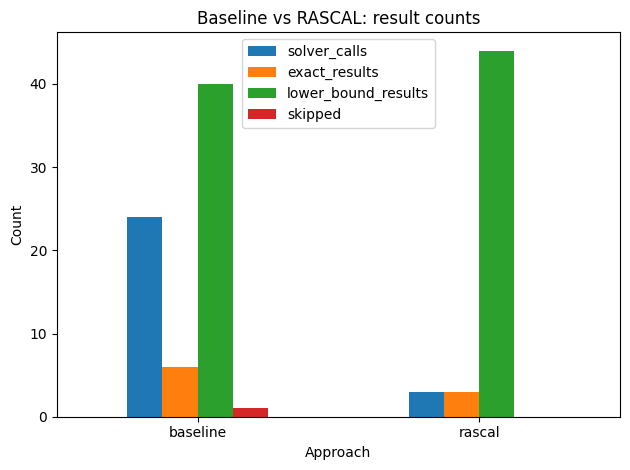

In [4]:
fig, ax = plt.subplots()
summary.set_index("approach")[["solver_calls", "exact_results", "lower_bound_results", "skipped"]].plot(kind="bar", ax=ax)
ax.set_title("Baseline vs RASCAL: result counts")
ax.set_ylabel("Count")
ax.set_xlabel("Approach")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Did RASCAL avoid solver calls?

This section identifies pairs where the baseline called the solver but the RASCAL approach did not.

In [5]:
solver_change = merged.assign(
    solver_avoided = (merged["solverCalled_baseline"] == 1) & (merged["solverCalled_rascal"] == 0),
    solver_newly_called = (merged["solverCalled_baseline"] == 0) & (merged["solverCalled_rascal"] == 1)
)

print("Solver avoided by RASCAL:", int(solver_change["solver_avoided"].sum()))
print("Solver newly called by RASCAL:", int(solver_change["solver_newly_called"].sum()))

cols_to_show = [
    "pair_id",
    "distance_baseline", "distance_rascal",
    "compute_mode_baseline", "compute_mode_rascal",
    "solverCalled_baseline", "solverCalled_rascal",
    "is_exact_baseline", "is_exact_rascal",
    "is_lower_bound_baseline", "is_lower_bound_rascal",
    "result_type_baseline", "result_type_rascal",
    "runtime_sec_baseline", "runtime_sec_rascal"
]
existing_cols = [c for c in cols_to_show if c in solver_change.columns]

avoided_solver_pairs = solver_change.loc[solver_change["solver_avoided"], existing_cols].copy()
display(avoided_solver_pairs)

Solver avoided by RASCAL: 21
Solver newly called by RASCAL: 0


,pair_id,distance_baseline,distance_rascal,compute_mode_baseline,compute_mode_rascal,solverCalled_baseline,solverCalled_rascal,is_exact_baseline,is_exact_rascal,is_lower_bound_baseline,is_lower_bound_rascal,result_type_baseline,result_type_rascal,runtime_sec_baseline,runtime_sec_rascal
0,1879,4.0,13.0,1.0,2,1,0,1,0,0,1,exact,lower_bound,18.516819,2.836139
1,3585,4.0,23.0,1.0,2,1,0,1,0,0,1,exact,lower_bound,5.443820,2.855316
5,18782,4.0,20.0,1.0,2,1,0,1,0,0,1,exact,lower_bound,2.916034,2.212581
6,28208,4.0,31.0,2.0,2,1,0,0,0,1,1,lower_bound,lower_bound,2.307590,2.379115
7,31479,5.0,14.0,2.0,2,1,0,0,0,1,1,lower_bound,lower_bound,7.024341,3.732469
8,31508,4.0,11.5,2.0,2,1,0,0,0,1,1,lower_bound,lower_bound,2.215978,2.170284
14,40255,4.0,12.5,2.0,2,1,0,0,0,1,1,lower_bound,lower_bound,2.995459,2.666028
15,42470,5.0,26.5,2.0,2,1,0,0,0,1,1,lower_bound,lower_bound,3.784056,2.394353
17,44757,5.0,23.0,2.0,2,1,0,0,0,1,1,lower_bound,lower_bound,7.368245,2.507898
20,47035,5.0,12.0,2.0,2,1,0,0,0,1,1,lower_bound,lower_bound,6.838682,3.069726


## Compare distances and lower bounds

Here we check whether RASCAL returned the same, higher, or lower value than the baseline.

For a lower-bound filter, a **higher lower bound** is generally stronger, as long as it does not exceed the true exact distance. If the exact solver result is unavailable, we can only compare against the baseline output, not prove correctness globally.


In [6]:
merged["distance_diff_rascal_minus_baseline"] = merged["distance_rascal"] - merged["distance_baseline"]

distance_summary = merged["distance_diff_rascal_minus_baseline"].describe()
display(distance_summary)

print("Same distance:", int(np.isclose(merged["distance_baseline"], merged["distance_rascal"], equal_nan=True).sum()))
print("RASCAL higher:", int((merged["distance_diff_rascal_minus_baseline"] > 0).sum()))
print("RASCAL lower:", int((merged["distance_diff_rascal_minus_baseline"] < 0).sum()))

changed_distances = merged.loc[
    ~np.isclose(merged["distance_baseline"], merged["distance_rascal"], equal_nan=True),
    existing_cols + ["distance_diff_rascal_minus_baseline"]
].copy()

display(changed_distances.sort_values("distance_diff_rascal_minus_baseline"))

count    46.000000
mean      6.130435
std       7.851705
min       0.000000
25%       0.000000
50%       0.000000
75%       9.000000
max      27.000000
Name: distance_diff_rascal_minus_baseline, dtype: float64

Same distance: 24
RASCAL higher: 22
RASCAL lower: 0


,pair_id,distance_baseline,distance_rascal,compute_mode_baseline,compute_mode_rascal,solverCalled_baseline,solverCalled_rascal,is_exact_baseline,is_exact_rascal,is_lower_bound_baseline,is_lower_bound_rascal,result_type_baseline,result_type_rascal,runtime_sec_baseline,runtime_sec_rascal,distance_diff_rascal_minus_baseline
11,33751,5.0,6.0,2.0,1,1,1,0,1,1,0,lower_bound,exact,8.978576,41.394121,1.0
36,93715,4.0,10.5,2.0,2,1,0,0,0,1,1,lower_bound,lower_bound,2.105665,1.844722,6.5
20,47035,5.0,12.0,2.0,2,1,0,0,0,1,1,lower_bound,lower_bound,6.838682,3.069726,7.0
32,87058,5.0,12.0,2.0,2,1,0,0,0,1,1,lower_bound,lower_bound,9.797898,3.004337,7.0
8,31508,4.0,11.5,2.0,2,1,0,0,0,1,1,lower_bound,lower_bound,2.215978,2.170284,7.5
38,97962,4.0,12.0,1.0,2,1,0,1,0,0,1,exact,lower_bound,5.553535,2.460554,8.0
14,40255,4.0,12.5,2.0,2,1,0,0,0,1,1,lower_bound,lower_bound,2.995459,2.666028,8.5
7,31479,5.0,14.0,2.0,2,1,0,0,0,1,1,lower_bound,lower_bound,7.024341,3.732469,9.0
30,85717,4.0,13.0,2.0,2,1,0,0,0,1,1,lower_bound,lower_bound,4.368586,3.095010,9.0
26,72734,5.0,14.0,2.0,2,1,0,0,0,1,1,lower_bound,lower_bound,6.394693,2.975148,9.0


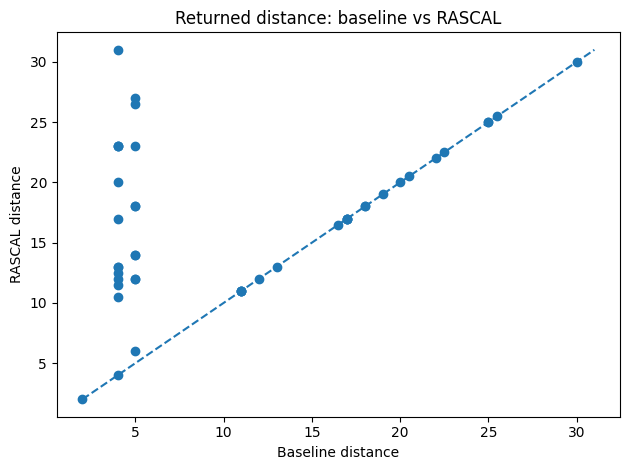

In [7]:
fig, ax = plt.subplots()
ax.scatter(merged["distance_baseline"], merged["distance_rascal"])
min_val = np.nanmin([merged["distance_baseline"].min(), merged["distance_rascal"].min()])
max_val = np.nanmax([merged["distance_baseline"].max(), merged["distance_rascal"].max()])
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")
ax.set_title("Returned distance: baseline vs RASCAL")
ax.set_xlabel("Baseline distance")
ax.set_ylabel("RASCAL distance")
plt.tight_layout()
plt.show()

## Runtime comparison

This checks whether RASCAL is faster or slower overall, and especially for pairs where the solver was avoided.

In [8]:
merged["runtime_diff_rascal_minus_baseline"] = merged["runtime_sec_rascal"] - merged["runtime_sec_baseline"]

runtime_summary = merged["runtime_diff_rascal_minus_baseline"].describe()
display(runtime_summary)

print("RASCAL faster:", int((merged["runtime_diff_rascal_minus_baseline"] < 0).sum()))
print("RASCAL slower:", int((merged["runtime_diff_rascal_minus_baseline"] > 0).sum()))

display(merged[[
    "pair_id",
    "runtime_sec_baseline",
    "runtime_sec_rascal",
    "runtime_diff_rascal_minus_baseline",
    "solverCalled_baseline",
    "solverCalled_rascal",
    "distance_baseline",
    "distance_rascal"
]].sort_values("runtime_diff_rascal_minus_baseline"))

count    47.000000
mean     -1.592423
std       9.977624
min     -56.701098
25%      -1.466128
50%      -0.045383
75%       0.026561
max      32.415545
Name: runtime_diff_rascal_minus_baseline, dtype: float64

RASCAL faster: 35
RASCAL slower: 12


,pair_id,runtime_sec_baseline,runtime_sec_rascal,runtime_diff_rascal_minus_baseline,solverCalled_baseline,solverCalled_rascal,distance_baseline,distance_rascal
24,61065,60.000000,3.298902,-56.701098,0,0,NaN,11.0
0,1879,18.516819,2.836139,-15.680680,1,0,4.0,13.0
32,87058,9.797898,3.004337,-6.793561,1,0,5.0,12.0
43,102018,9.195443,2.830572,-6.364871,1,0,5.0,18.0
17,44757,7.368245,2.507898,-4.860347,1,0,5.0,23.0
20,47035,6.838682,3.069726,-3.768956,1,0,5.0,12.0
26,72734,6.394693,2.975148,-3.419545,1,0,5.0,14.0
7,31479,7.024341,3.732469,-3.291873,1,0,5.0,14.0
38,97962,5.553535,2.460554,-3.092981,1,0,4.0,12.0
1,3585,5.443820,2.855316,-2.588504,1,0,4.0,23.0


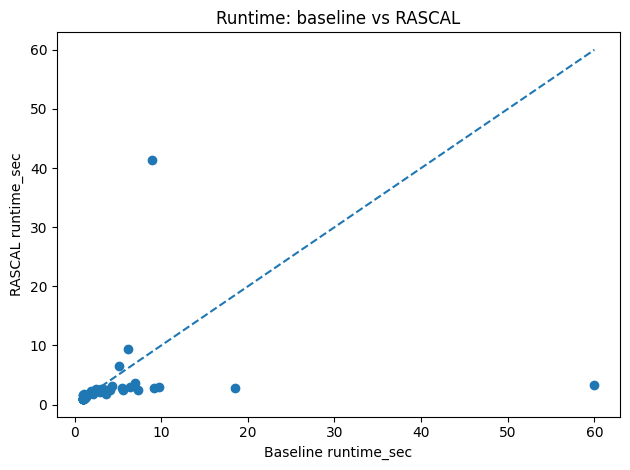

In [9]:
fig, ax = plt.subplots()
ax.scatter(merged["runtime_sec_baseline"], merged["runtime_sec_rascal"])
min_val = np.nanmin([merged["runtime_sec_baseline"].min(), merged["runtime_sec_rascal"].min()])
max_val = np.nanmax([merged["runtime_sec_baseline"].max(), merged["runtime_sec_rascal"].max()])
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")
ax.set_title("Runtime: baseline vs RASCAL")
ax.set_xlabel("Baseline runtime_sec")
ax.set_ylabel("RASCAL runtime_sec")
plt.tight_layout()
plt.show()